In [34]:
import numpy as np
from scipy.integrate import quad
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator
from scipy.special import kv
import matplotlib.pyplot as plt

In [28]:
def dimensionless_sqa_integral(chi):
    # Интеграл из формулы (3.7) [4]
    integrand = lambda v: ((9 - v**2) / (1 - v**2)) * kv(2/3, 8 / (3 * (1 - v**2) * chi))
    res, _ = quad(integrand, -1, 1)
    return res

chi_grid = np.logspace(-2, 2, 500) 
table_values = np.array([dimensionless_sqa_integral(c) for c in chi_grid])
np.savez('sqa_lookup_table.npz', chi=chi_grid, values=table_values)

In [36]:
prob_grid = np.linspace(0, 1, 1000)
chi_grid = np.logspace(-1, 20, 1000)
epsilon_table = np.zeros((len(chi_grid), len(prob_grid)))
cdf_table = np.zeros((len(chi_grid), len(prob_grid)))

# Сетка для интегрирования (от 0 до 0.5 по симметрии)
e_integration_grid = np.linspace(1e-5, 0.5, 500)

for i, chi in enumerate(chi_grid):
    # 1. Расчет PDF
    term_bessel = 1.0 / (3.0 * chi * e_integration_grid * (1.0 - e_integration_grid))
    factor = (2.0 + e_integration_grid * (1.0 - e_integration_grid)) / (e_integration_grid * (1.0 - e_integration_grid))
    pdf_values = factor * kv(2/3, term_bessel)
    
    # 2. Вычисляем CDF
    cdf_values = cumulative_trapezoid(pdf_values, e_integration_grid, initial=0)
    total_sum = cdf_values[-1]

    # 3. Обработка случая, когда PDF хоть где-то не ноль
    if total_sum > 1e-100: # используем очень малое число вместо 0
        cdf_values /= total_sum
        
        # УДАЛЯЕМ ДУБЛИКАТЫ: берем только те индексы, где CDF реально растет
        # Это убирает плоские участки, на которых спотыкается interp1d
                # 1. Распаковываем кортеж: vals нам не нужны, нужны только целочисленные индексы idx
        _, idx = np.unique(cdf_values, return_index=True)
        
        # 2. Сортируем индексы, так как np.unique возвращает их в порядке возрастания ЗНАЧЕНИЙ,
        # а для интерполяции нам нужно сохранить исходный порядок сетки по e_integration_grid
        idx = np.sort(idx)

        # 3. Проверяем, что уникальных точек хотя бы 2, иначе интерполяция невозможна
        if len(idx) > 1:
            inv_func = interp1d(cdf_values[idx], 
                                e_integration_grid[idx], 
                                kind='linear', fill_value="extrapolate")
            epsilon_table[i, :] = inv_func(prob_grid)
        else:
            epsilon_table[i, :] = 0.5

# Проверка на наличие конечных чисел перед интерполяцией
if not np.isfinite(epsilon_table).all():
    print("В таблице все еще есть NaN!")

# for row in cdf_table[:100]:
#     print("".join(f"{item==0}" for item in row))

CDF_Interpolator = RegularGridInterpolator(
                points=(np.log10(chi_grid), prob_grid),
                values=epsilon_table,
                method='cubic',
                bounds_error=False,
                fill_value=0.5         # значение по умолчанию при выходе за границы
            )

In [25]:
chi1 = 1e1
sum_val = 0
a = 100000
for _ in range(a):
    rnd = np.random.random()
    
    # 1. Определяем, в какую половину попали (симметрия)
    is_mirrored = rnd > 0.5
    # Приводим rnd к диапазону 0...1 для нашей "половинчатой" таблицы
    u_normalized = (rnd if not is_mirrored else 1.0 - rnd) * 2.0
    
    # 2. Получаем epsilon из таблицы (0...0.5)
    n = CDF_Interpolator([np.log10(chi1), u_normalized])
    
    # 3. Если попали во вторую половину, зеркалим значение
    actual_epsilon = n if not is_mirrored else 1.0 - n
    
    sum_val += actual_epsilon

print("Mean:", sum_val / a)

Mean: [0.50077284]


In [37]:
np.savez_compressed(
    "epsilon_interpolation_data.npz", 
    epsilon_table=epsilon_table,
    chi_grid=chi_grid,
    prob_grid=prob_grid
)

print("Создана и сохранена таблица интерполяции эпсилон")

Создана и сохранена таблица интерполяции эпсилон


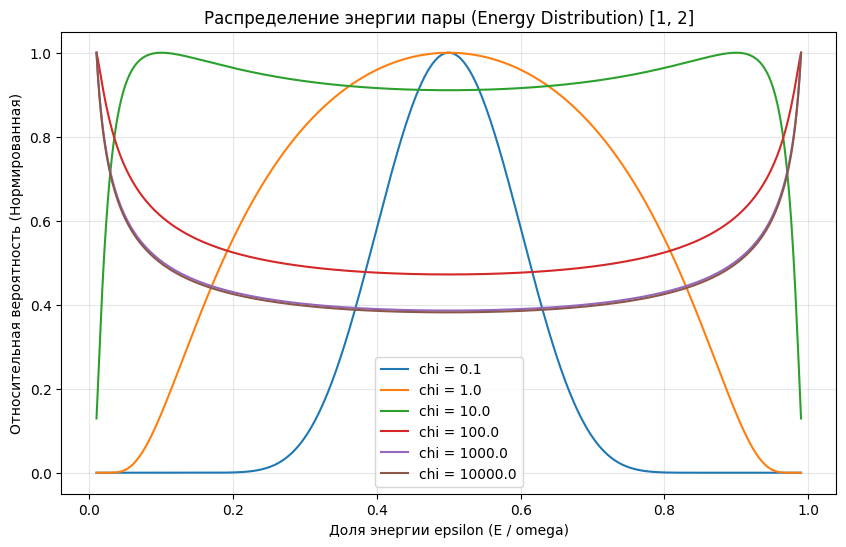

In [78]:
def dR_depsilon(epsilon, chi):
    """
    Вычисляет относительную вероятность dR/de согласно уравнению (19) [1].
    Константы (alpha, m^2) опущены, так как они влияют только на масштаб.
    """
    # Защита от деления на 0 на границах
    eps_prod = epsilon * (1 - epsilon)
    
    # Аргумент функции Бесселя: 1 / (3 * chi * eps * (1 - eps))
    z = 1.0 / (3.0 * chi * eps_prod)
    
    # Множитель: [2 + eps(1-eps)] / [eps(1-eps)]
    factor = (2.0 + eps_prod) / eps_prod
    
    return factor * kv(2/3, z)

# Параметры визуализации
chis = np.logspace(-1, 4, 6)
epsilon = np.linspace(0.01, 0.99, 500)

plt.figure(figsize=(10, 6))

for chi in chis:
    y = dR_depsilon(epsilon, chi)
    # Нормируем для наглядности (чтобы площади или пики были сравнимы)
    plt.plot(epsilon, y / np.max(y), label=f'chi = {chi}')

plt.title('Распределение энергии пары (Energy Distribution) [1, 2]')
plt.xlabel('Доля энергии epsilon (E / omega)')
plt.ylabel('Относительная вероятность (Нормированная)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()